In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/SpamClassifierProject/datasets/dataset1.csv',
    encoding='latin-1'
)

In [8]:
df.columns

Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')

In [9]:

print(df.shape)

print(df['label_num'].value_counts())

print(df.isnull().sum())

print(df.duplicated().sum())

(5171, 4)
label_num
0    3672
1    1499
Name: count, dtype: int64
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64
0


In [10]:
df = df[['text', 'label_num']]

In [11]:
df.head()

,text,label_num
0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\r\nthis deal is t...,0


In [12]:
df.columns = ['text', 'label']

In [13]:
df.head()

,text,label
0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\r\nthis deal is t...,0


In [14]:
df.columns

Index(['text', 'label'], dtype='object')

#Doing text Text Preprocessing Setup:

#first installing required librarires:

In [15]:
import nltk
import re
import string

nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#Creating Stemmer Object

In [16]:
ps = PorterStemmer()

#*Basic Preprocessing Function*

In [17]:
def preprocess_text(text):

    text = str(text)

    # lowercase er jonno
    text = text.lower()

    # remove urls er jonno
    text = re.sub(r'http\S+', '', text)

    # remove numbers er jonno
    text = re.sub(r'\d+', '', text)

    # remove punctuation er jonno
    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    # tokenize korer jonno
    words = text.split()

    # removing stopwords
    words = [
        word
        for word in words
        if word not in stopwords.words('english')
    ]

    # stemming er jonno
    words = [
        ps.stem(word)
        for word in words
    ]

    return " ".join(words)

# function test kori

In [18]:
sample = "Congratulations! You have won 10000 dollars. Click http://abc.com now."

print(preprocess_text(sample))

congratul dollar click


**Applying Preprocessing on Entire Dataset**

In [19]:
df['processed_text'] = df['text'].apply(preprocess_text)

*verifying*

In [20]:
df[['text', 'processed_text']].head()

,text,processed_text
0,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter follow note gave ...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom januari see attach file hplnol...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho around wonder ti...
3,"Subject: photoshop , windows , office . cheap ...",subject photoshop window offic cheap main tren...
4,Subject: re : indian springs\r\nthis deal is t...,subject indian spring deal book teco pvr reven...


*Checking processing worked correctly*

In [21]:
print(df['processed_text'].iloc[0])

subject enron methanol meter follow note gave monday preliminari flow data provid daren pleas overrid pop daili volum present zero reflect daili activ obtain ga control chang need asap econom purpos


# TF-IDF vectorization

*converting text to numerical features:*

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Creating TF-IDF object
vectorizer = TfidfVectorizer()

# Converting processed text into numerical features
X = vectorizer.fit_transform(df['processed_text'])

# Targeting variable
y = df['label']

# Checking shape
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5171, 37932)
y shape: (5171,)


In [23]:
print(type(X))

<class 'scipy.sparse._csr.csr_matrix'>


# it's train-test splitting time

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4136, 37932)
X_test : (1035, 37932)
y_train: (4136,)
y_test : (1035,)


  #now we are trainning our naive bayes model:

In [25]:
from sklearn.naive_bayes import MultinomialNB

# Createing model
model = MultinomialNB()

# Training model
model.fit(X_train, y_train)

MultinomialNB()

# Prediction:

In [26]:
y_pred = model.predict(X_test)

# Accuracy

In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9256038647342996


In [28]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [29]:
y_pred = model.predict(X_test)

In [30]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9256038647342996


# Confusion matrix:

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[742   0]
 [ 77 216]]


# Confusion matrix visualization:

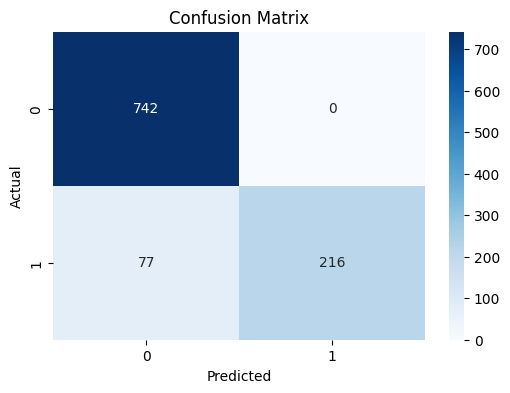

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# here is the classification report

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       742
           1       1.00      0.74      0.85       293

    accuracy                           0.93      1035
   macro avg       0.95      0.87      0.90      1035
weighted avg       0.93      0.93      0.92      1035



In [34]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[742   0]
 [ 77 216]]


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       742
           1       1.00      0.74      0.85       293

    accuracy                           0.93      1035
   macro avg       0.95      0.87      0.90      1035
weighted avg       0.93      0.93      0.92      1035



# saving the accuracy:

In [36]:
acc1 = accuracy

print("Dataset 1 Accuracy =", round(acc1*100,2), "%")

Dataset 1 Accuracy = 92.56 %


# Saving this Pipeline as a function

In [37]:
def evaluate_dataset(df):

    # copy dataframe
    df = df.copy()

    # preprocess
    df['processed_text'] = df['text'].apply(preprocess_text)

    # TF-IDF
    vectorizer = TfidfVectorizer()

    X = vectorizer.fit_transform(df['processed_text'])
    y = df['label']

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # model
    model = MultinomialNB()
    model.fit(X_train, y_train)

    # prediction
    y_pred = model.predict(X_test)

    # accuracy
    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

# Loading dataset-2:

In [38]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/SpamClassifierProject/datasets/dataset2.csv',
    encoding='latin-1'
)

*reading dataset 2:*

In [42]:
print(df.columns)
print(df.shape)
df.head()

Index(['label', 'message'], dtype='object')
(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Preparing dataset 2

In [44]:
df = df.rename(columns={
    'message':'text'
})

# Converting ham/spam ----> 0/1

In [46]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

# Verifying

In [48]:
print(df['label'].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


# accuracy of dataset2

In [49]:
import pandas as pd

# Reloading df2 to correct the NaN values and ensure original state.
df2 = pd.read_csv(
    '/content/drive/MyDrive/SpamClassifierProject/datasets/dataset2.csv',
    encoding='latin-1'
)

# Renaming 'message' column to 'text' as expected by evaluate_dataset function.
df2 = df2.rename(columns={'message':'text'})

acc2 = evaluate_dataset(df2)

print("Dataset 2 Accuracy =", round(acc2*100,2), "%")

Dataset 2 Accuracy = 96.86 %


#for saving purpose

In [50]:
acc1 = 0.9256038647342996
acc2 = 0.9686

comparison = pd.DataFrame({
    'Dataset': ['Dataset 1', 'Dataset 2'],
    'Accuracy': [acc1, acc2]
})

comparison

,Dataset,Accuracy
0,Dataset 1,0.925604
1,Dataset 2,0.968600


# Dataset 3 loading:

In [51]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/SpamClassifierProject/datasets/dataset3.csv',
    encoding='latin-1'
)

*reading*

In [54]:
print(df.columns)
print(df.shape)
df.head()

Index(['text', 'spam'], dtype='object')
(5728, 2)


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


# REnameing the columns:

In [56]:
df = df.rename(columns={
    'spam': 'label'
})

# checking labels:

In [58]:
print(df['label'].value_counts())

label
0    4360
1    1368
Name: count, dtype: int64


# Accuracy of dataset-3:

In [60]:
acc3 = evaluate_dataset(df)

print("Dataset 3 Accuracy =", round(acc3*100,2), "%")

Dataset 3 Accuracy = 88.31 %


# Loading dataset-4

In [61]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/SpamClassifierProject/datasets/dataset4.csv',
    encoding='latin-1'
)

**reading**

# Dataset 4-er columns and shape

In [64]:
print(df.columns)
print(df.shape)

df.head()

Index(['target', 'text'], dtype='object')
(10961, 2)


,target,text
0,spam,Congratulations! You've been selected for a lu...
1,spam,URGENT: Your account has been compromised. Cli...
2,spam,You've won a free iPhone! Claim your prize by ...
3,spam,Act now and receive a 50% discount on all purc...
4,spam,Important notice: Your subscription will expir...


# preparing dataset 4

In [66]:
df = df.rename(columns={
    'target': 'label'
})

*checking labels*

In [68]:
print(df['label'].value_counts())

label
ham     8555
spam    2406
Name: count, dtype: int64


# converting labels:

In [70]:
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

#verifying

In [72]:
print(df['label'].value_counts())

label
0    8555
1    2406
Name: count, dtype: int64


# accuracy of dataset-4

In [73]:
import pandas as pd

# Reload df4 to ensure its original state from the CSV
df4 = pd.read_csv(
    '/content/drive/MyDrive/SpamClassifierProject/datasets/dataset4.csv',
    encoding='latin-1'
)

# Rename 'target' column to 'label' as expected by evaluate_dataset function.
df4 = df4.rename(columns={'target': 'label'})

# Convert 'ham' and 'spam' strings to numerical labels 0 and 1.
# This step is necessary because the original CSV contains 'spam'/'ham' strings
# and the evaluate_dataset function expects numeric labels.
df4['label'] = df4['label'].map({'ham': 0, 'spam': 1})

acc4 = evaluate_dataset(df4)

print("Dataset 4 Accuracy =", round(acc4*100,2), "%")

Dataset 4 Accuracy = 89.38 %


In [74]:
acc1 = 0.9256038647342996
acc2 = 0.9686
acc3 = 0.8831
acc4 = 0.8942

comparison = pd.DataFrame({
    'Dataset': [
        'Dataset 1',
        'Dataset 2',
        'Dataset 3',
        'Dataset 4'
    ],
    'Accuracy': [
        acc1,
        acc2,
        acc3,
        acc4
    ]
})

comparison

,Dataset,Accuracy
0,Dataset 1,0.925604
1,Dataset 2,0.968600
2,Dataset 3,0.883100
3,Dataset 4,0.894200


In [75]:
comparison['Accuracy (%)'] = comparison['Accuracy'] * 100

comparison

,Dataset,Accuracy,Accuracy (%)
0,Dataset 1,0.925604,92.560386
1,Dataset 2,0.968600,96.860000
2,Dataset 3,0.883100,88.310000
3,Dataset 4,0.894200,89.420000


In [78]:
import pandas as pd

# --- Processing for Dataset 1 ---
df1 = pd.read_csv(
    '/content/drive/MyDrive/SpamClassifierProject/datasets/dataset1.csv',
    encoding='latin-1'
)
df1 = df1[['text', 'label_num']]
df1.columns = ['text', 'label']
df1_final = df1[['text', 'label']].copy()

# --- Processing for Dataset 2 ---
df2 = pd.read_csv(
    '/content/drive/MyDrive/SpamClassifierProject/datasets/dataset2.csv',
    encoding='latin-1'
)
df2 = df2.rename(columns={'message':'text'})
df2['label'] = df2['label'].map({
    'ham':0,
    'spam':1
})
df2_final = df2[['text', 'label']].copy()

# --- Processing for Dataset 3 ---
df3 = pd.read_csv(
    '/content/drive/MyDrive/SpamClassifierProject/datasets/dataset3.csv',
    encoding='latin-1'
)
df3 = df3.rename(columns={'spam': 'label'})
df3_final = df3[['text', 'label']].copy()

# --- Processing for Dataset 4 ---
df4 = pd.read_csv(
    '/content/drive/MyDrive/SpamClassifierProject/datasets/dataset4.csv',
    encoding='latin-1'
)
df4 = df4.rename(columns={'target': 'label'})
df4['label'] = df4['label'].map({
    'ham': 0,
    'spam': 1
})
df4_final = df4[['text', 'label']].copy()

In [79]:
print(df1_final.columns)
print(df2_final.columns)
print(df3_final.columns)
print(df4_final.columns)

Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')


# merging 4 datasets:

In [80]:
merged_df = pd.concat(
    [
        df1_final,
        df2_final,
        df3_final,
        df4_final
    ],
    ignore_index=True
)

print("Merged Shape:", merged_df.shape)

Merged Shape: (27432, 2)


In [81]:
#checking lable distribution:

In [82]:
print(
    merged_df['label']
    .value_counts(dropna=False)
)

label
0    21412
1     6020
Name: count, dtype: int64


# merged dataset accuracy

In [83]:
merged_acc = evaluate_dataset(merged_df)

print(
    "Merged Dataset Accuracy =",
    round(merged_acc*100,2),
    "%"
)

Merged Dataset Accuracy = 93.15 %


# final Comparison er Code

In [84]:
comparison = pd.DataFrame({
    'Dataset': [
        'Dataset 1',
        'Dataset 2',
        'Dataset 3',
        'Dataset 4',
        'Merged Dataset'
    ],
    'Accuracy (%)': [
        round(acc1*100,2),
        round(acc2*100,2),
        round(acc3*100,2),
        round(acc4*100,2),
        round(merged_acc*100,2)
    ]
})

comparison

,Dataset,Accuracy (%)
0,Dataset 1,92.56
1,Dataset 2,96.86
2,Dataset 3,88.31
3,Dataset 4,89.42
4,Merged Dataset,93.15


# Accuracy-graph:

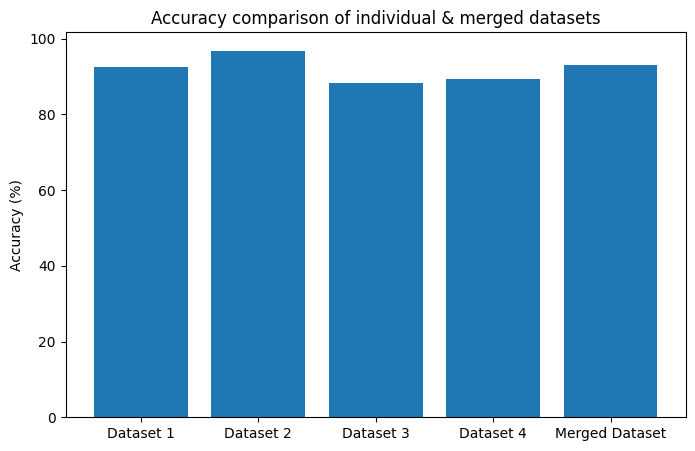

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison['Dataset'],
    comparison['Accuracy (%)']
)

plt.ylabel('Accuracy (%)')
plt.title('Accuracy comparison of individual & merged datasets')

plt.show()

# Saving the final model:

In [86]:
import joblib

joblib.dump(model, "spam_classifier.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [87]:
import os

print(os.listdir())

['.config', 'spam_classifier.pkl', 'tfidf_vectorizer.pkl', 'drive', 'sample_data']


In [88]:
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [89]:
print(type(model))

<class 'sklearn.naive_bayes.MultinomialNB'>


In [90]:
print(model)

MultinomialNB()


# Final model training:

In [91]:
merged_df['processed_text'] = merged_df['text'].apply(preprocess_text)

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(
    merged_df['processed_text']
)

y = merged_df['label']

In [93]:
from sklearn.naive_bayes import MultinomialNB

final_model = MultinomialNB()

final_model.fit(X, y)

print("Final Model Trained Successfully")

Final Model Trained Successfully


#saving:

In [94]:
import joblib

joblib.dump(final_model,
            "final_spam_classifier.pkl")

joblib.dump(vectorizer,
            "final_tfidf_vectorizer.pkl")

print("Saved Successfully")

Saved Successfully


In [95]:
import os

print(os.listdir())

['.config', 'spam_classifier.pkl', 'tfidf_vectorizer.pkl', 'final_spam_classifier.pkl', 'final_tfidf_vectorizer.pkl', 'drive', 'sample_data']


# training-test split on mergerd data

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Traininng model again:

In [97]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#confusion matrix:

In [98]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4217   74]
 [ 128 1068]]


#drawing confusion matrix:

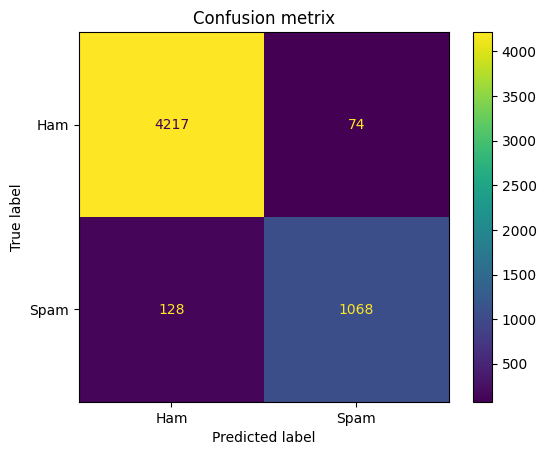

In [99]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()

plt.title("Confusion metrix")
plt.show()


#saving figure:

<Figure size 600x400 with 0 Axes>

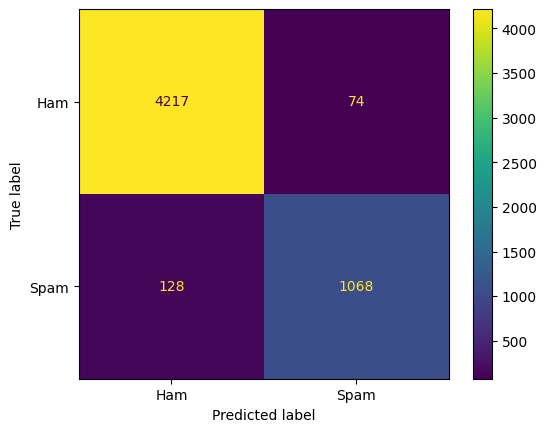

In [100]:
plt.figure(figsize=(6,4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()


plt.savefig(
    '/content/drive/MyDrive/SpamClassifierProject/graphs/confusion_matrix.png',
    bbox_inches='tight'
)

plt.show()

#classification report:

In [101]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4291
           1       0.94      0.89      0.91      1196

    accuracy                           0.96      5487
   macro avg       0.95      0.94      0.95      5487
weighted avg       0.96      0.96      0.96      5487



#saving accuracy comparison graph

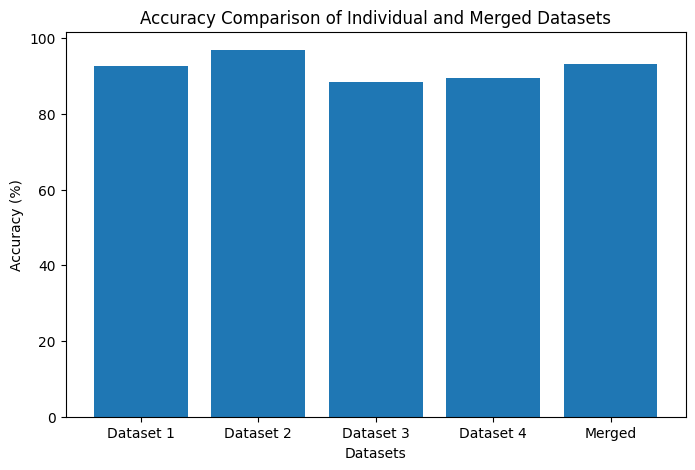

In [102]:
import matplotlib.pyplot as plt

datasets = [
    'Dataset 1',
    'Dataset 2',
    'Dataset 3',
    'Dataset 4',
    'Merged'
]

accuracies = [
    92.56,
    96.86,
    88.31,
    89.42,
    93.15
]

plt.figure(figsize=(8,5))

plt.bar(
    datasets,
    accuracies
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Datasets")
plt.title("Accuracy Comparison of Individual and Merged Datasets")

plt.savefig(
    "/content/drive/MyDrive/SpamClassifierProject/graphs/accuracy_comparison.png",
    bbox_inches="tight"
)


plt.show()

#for checking purpose:

In [103]:
import os

print(os.listdir())

['.config', 'spam_classifier.pkl', 'tfidf_vectorizer.pkl', 'final_spam_classifier.pkl', 'final_tfidf_vectorizer.pkl', 'drive', 'sample_data']


#model save in drive

In [104]:
import joblib

joblib.dump(
    final_model,
    '/content/drive/MyDrive/SpamClassifierProject/models/final_spam_classifier.pkl'
)

joblib.dump(
    vectorizer,
    '/content/drive/MyDrive/SpamClassifierProject/models/final_tfidf_vectorizer.pkl'
)

['/content/drive/MyDrive/SpamClassifierProject/models/final_tfidf_vectorizer.pkl']

In [105]:
import joblib

# Load Final Model
model = joblib.load("final_spam_classifier.pkl")
vectorizer = joblib.load("final_tfidf_vectorizer.pkl")

while True:

    msg = input("Enter Message (type 'exit' to stop): ")

    if msg.lower() == "exit":
        print("Program Ended.")
        break

    # Preprocess
    msg_clean = preprocess_text(msg)

    # Vectorize
    msg_vector = vectorizer.transform([msg_clean])

    # Predict
    prediction = model.predict(msg_vector)

    if prediction[0] == 1:
        print("🚨 SPAM MESSAGE\n")
    else:
        print("✅ HAM (NOT SPAM)\n")

Enter Message (type 'exit' to stop): hi
✅ HAM (NOT SPAM)

Enter Message (type 'exit' to stop): exit
Program Ended.


In [106]:
!pip install gradio

In [107]:
import gradio as gr
import joblib

model = joblib.load("final_spam_classifier.pkl")
vectorizer = joblib.load("final_tfidf_vectorizer.pkl")

def predict_spam(message):

    msg_clean = preprocess_text(message)

    msg_vector = vectorizer.transform([msg_clean])

    prediction = model.predict(msg_vector)

    if prediction[0] == 1:
        return "🚨 SPAM"
    else:
        return "✅ HAM"

app = gr.Interface(
    fn=predict_spam,
    inputs="text",
    outputs="text",
    title="AI Spam Message Classifier"
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4a7b795b1a903c7e78.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
